# Assignment 2. Sensitivity Analysis: Which Inputs Matter?

**Course:** EPA141A Model Based Decision Making — Delft University of Technology  
**Model:** JUSTICE v0.1.4


## Learning Outcomes

After completing this assignment you will be able to:
1. Explain the purpose of sensitivity analysis and when to apply it.
2. Compute **Extra-Trees feature importance** using the EMA Workbench `feature_scoring` module.
3. Run a **Morris elementary effects** analysis with SALib and interpret **μ\*** and **σ**.
4. Explain why Sobol variance decomposition requires smooth, quasi-monotonic model responses,
   and identify the diagnostic symptoms (S₁ > 1, S₁ < 0) that indicate it has been misapplied.
5. Compare sensitivity rankings under **no abatement** vs. **moderate abatement** and explain
   what policy-conditional sensitivity means for decision-making.


---

## Background

Assignment 1 showed that four uncertain parameters produce a wide spread in all four outcomes.
Sensitivity analysis (SA) answers the follow-up question: **which inputs are responsible for that spread?**

Knowing this helps to:
- Prioritise where to invest in further research (reduce the most influential uncertainties first).
- Identify parameters that can safely be fixed without losing model fidelity.
- Understand whether the dominant driver of variability is physical (`ecs_ensemble`) or normative (ρ, η, δ).

We use two complementary methods that together give a complete picture:

**Extra-Trees feature importance** (EMA Workbench `feature_scoring`)  
Fits an ensemble of extremely randomised regression trees on the LHS ensemble from Step 2.
Reports how much each parameter reduces prediction variance across all trees. Fast, non-parametric,
and captures non-linear effects including `ecs_ensemble` (a discrete non-monotonic index).

**Morris elementary effects** (SALib `morris`)  
Perturbs each input one at a time from many random starting points and records the resulting
output change. Computes μ\* (mean absolute effect — importance) and σ (standard deviation —
non-linearity / interaction proxy). Morris handles non-monotonic and sign-changing model
responses reliably, making it the appropriate complement to ET for JUSTICE's welfare function.

### Why not Sobol for this model?
Sobol variance decomposition requires smooth, quasi-monotonic outputs. JUSTICE's `welfare`
changes sign at η ≈ 1.05 — from +856 at η = 0.9 to −551 at η = 1.1 — because the utility
curvature parameter changes the sign of the welfare aggregation. This makes the Saltelli
estimator unstable (S₁ > 1, S₁ < 0 are the diagnostic symptoms). Morris and ET are the
correct tools for this model.

## Setup — Imports and model configuration

The cell below imports all required packages (including SALib for Morris and EMA Workbench for Extra-Trees), configures logging, and defines the shared name lists for outcomes, parameters, and policies used throughout the analysis.

In [1]:
import os, sys
# ── Add JUSTICE-main to sys.path so justice internal imports resolve ───────────
try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath('.')
_justice_root = os.path.normpath(os.path.join(_NOTEBOOK_DIR, '../JUSTICE-main'))

_PLOTS_DIR = os.path.join(_NOTEBOOK_DIR, "plots")
os.makedirs(_PLOTS_DIR, exist_ok=True)
if _justice_root not in sys.path:
    sys.path.insert(0, _justice_root)
os.chdir(_justice_root)

import warnings; warnings.filterwarnings("ignore")
import os
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from SALib.sample import morris as morris_sample
from SALib.analyze import morris as morris_analyze
from ema_workbench import (
    Model, RealParameter, ScalarOutcome, ArrayOutcome,
    perform_experiments, ema_logging, Sample,
    SequentialEvaluator,
)
from ema_workbench.em_framework.evaluators import Samplers
from ema_workbench.analysis import feature_scoring
from justice.model import JUSTICE
from justice.util.enumerations import WelfareFunction
from justice.objectives.objective_functions import years_above_temperature_threshold

ema_logging.log_to_stderr(logging.WARNING)

OBJECTIVES   = ["welfare", "years_above_temperature_threshold",
                "welfare_loss_damage", "welfare_loss_abatement"]
PARAMS       = ["rho", "eta", "delta", "ecs_ensemble"]
PARAMS_NORM  = ["rho", "eta", "delta"]
POLICY_NAMES = ["no_abatement", "moderate_abatement"]
palette      = {"no_abatement": "steelblue", "moderate_abatement": "darkorange"}

print("Imports OK")
import matplotlib.path as _mpath
def _patched_path_deepcopy(self, memo=None):
    if memo is None: memo = {}
    new_path = _mpath.Path.__new__(_mpath.Path)
    memo[id(self)] = new_path
    verts = self._vertices.copy()
    codes = self._codes.copy() if self._codes is not None else None
    new_path.__init__(verts, codes,
                      _interpolation_steps=self._interpolation_steps, readonly=False)
    return new_path
_mpath.Path.__deepcopy__ = _patched_path_deepcopy

Imports OK


---

## Step 1 — Define the model

The model wrapper is identical to Assignment 1: four uncertain parameters plus the `ecr_plateau` lever.

**Task 1.1** — Complete `justice_model` so it:
1. Hard-resets JUSTICE and instantiates it with the given `ecs_ensemble` index.
2. Sets ρ and η on both `model.economy` and `model.welfare_function`.
3. Scales the three damage coefficients by δ.
4. Runs with a uniform ECR equal to `ecr_plateau` across all regions and returns all four scalar outcomes plus the global mean temperature trajectory.

**Task 1.2** — Run the smoke test below and confirm the four outcomes are positive and in plausible ranges.

In [2]:
def justice_model(rho=0.015, eta=1.45, delta=1.0, ecs_ensemble=1, ecr_plateau=0.0):
    """EMA Workbench function model — 4 uncertain parameters + ECR lever.

    Parameters
    ----------
    ecr_plateau : float
        Emission control rate applied uniformly across all regions and timesteps.
        0.0 = no abatement; 0.4 = 40% moderate abatement.
    """
    JUSTICE.hard_reset()
    ensemble_idx = int(np.round(np.clip(ecs_ensemble, 1, 1001)))
    model = JUSTICE(
        start_year=2015, end_year=2300, timestep=1,
        scenario=2, climate_ensembles=ensemble_idx, stochastic_run=False,
        social_welfare_function=WelfareFunction.UTILITARIAN,
    )
    model.economy.pure_rate_of_social_time_preference = float(rho)
    model.economy.elasticity_of_marginal_utility_of_consumption = float(eta)
    model.welfare_function.pure_rate_of_social_time_preference = float(rho)
    model.welfare_function.elasticity_of_marginal_utility_of_consumption = float(eta)
    model.damage_function.coefficient_a                  *= float(delta)
    model.damage_function.coefficient_b                  *= float(delta)
    model.damage_function.damage_gdp_ratio_with_gradient *= float(delta)

    ecr = np.full(model.emission_control_rate.shape[:2], float(ecr_plateau))
    model.run(emission_control_rate=ecr, endogenous_savings_rate=True)
    datasets = model.evaluate()

    welfare = float(np.abs(np.squeeze(datasets["welfare"])))
    yat     = float(np.squeeze(
        years_above_temperature_threshold(datasets["global_temperature"], 2.0)
    ))
    _, _, _, wl_dmg = model.welfare_function.calculate_welfare(
        datasets["damage_cost_per_capita"], welfare_loss=True)
    _, _, _, wl_abt = model.welfare_function.calculate_welfare(
        datasets["abatement_cost_per_capita"], welfare_loss=True)
    temp = np.squeeze(datasets["global_temperature"])
    if temp.ndim == 2:
        temp = temp.mean(axis=0)

    return {
        "welfare":                           welfare,
        "years_above_temperature_threshold": yat,
        "welfare_loss_damage":               float(np.abs(np.squeeze(wl_dmg))),
        "welfare_loss_abatement":            float(np.abs(np.squeeze(wl_abt))),
        "temperature_trajectory":            temp.astype(float),
    }

# Smoke test
test = justice_model()
for k, v in test.items():
    if isinstance(v, np.ndarray):
        print(f"  {k}: array shape {v.shape}, range [{v.min():.2f}, {v.max():.2f}]")
    else:
        print(f"  {k}: {v:.4f}")

  welfare: 103.7211
  years_above_temperature_threshold: 259.0000
  welfare_loss_damage: 3980.5410
  welfare_loss_abatement: 74364.1321
  temperature_trajectory: array shape (286,), range [1.20, 6.01]


## Step 2 — EMA model setup and LHS ensemble

**Task 2.1** — Wrap `justice_model` in a `Model` object with the same four uncertain
parameters and four scalar outcomes as Assignment 1.

**Task 2.2** — Run 100 LHS scenarios under each policy using `SequentialEvaluator`. This
ensemble is used as input to the Extra-Trees analysis in Step 3.

**Task 2.3** — How does the `welfare_loss_abatement` distribution compare between the
two policies? Explain the difference.

---

*Note: The outcome distributions for both policies are fully explored in **Assignment 1**
(Steps 3–4). The key finding there was that `years_above_temperature_threshold` shows the
clearest policy separation (~15 year shift), while `welfare` distributions overlap almost
entirely — policy signal is overwhelmed by parametric uncertainty. SA in this assignment
explains **why** those distributions are wide and which specific inputs drive the spread.*

In [3]:
em_model = Model('JUSTICE', function=justice_model)

em_model.uncertainties = [
    RealParameter('rho',          0.001,    0.030),
    RealParameter('eta',          0.5,      1.5),
    RealParameter('delta',        0.5,      2.0),
    RealParameter('ecs_ensemble', 1,     1001),
]

em_model.levers = [
    RealParameter('ecr_plateau', 0.0, 1.0),
]

em_model.outcomes = [
    ScalarOutcome('welfare'),
    ScalarOutcome('years_above_temperature_threshold'),
    ScalarOutcome('welfare_loss_damage'),
    ScalarOutcome('welfare_loss_abatement'),
    ArrayOutcome('temperature_trajectory'),
]

policies = [
    Sample('no_abatement',       ecr_plateau=0.0),
    Sample('moderate_abatement', ecr_plateau=0.4),
]

with SequentialEvaluator(em_model) as evaluator:
    experiments, outcomes = evaluator.perform_experiments(scenarios=100, policies=policies)

df_results = pd.DataFrame({k: v for k, v in outcomes.items() if k != 'temperature_trajectory'})
df_results['policy'] = experiments['policy'].values

print(f"experiments shape : {experiments.shape}")
print(f"policy counts     :\n{df_results['policy'].value_counts()}")
display(df_results[OBJECTIVES].describe().round(4))

100%|████████████████████████████████████████| 200/200 [03:28<00:00,  1.04s/it]

experiments shape : (200, 8)
policy counts     :
policy
moderate_abatement    100
no_abatement          100
Name: count, dtype: int64


,welfare,years_above_temperature_threshold,welfare_loss_damage,welfare_loss_abatement
count,200.0000,200.0000,200.0000,200.0000
mean,1006.0134,237.8150,1509.5106,9694.5336
std,1797.6325,18.0048,2042.9754,33566.5726
min,54.2134,171.0000,28.2402,1.9572
25%,239.3716,229.0000,250.4400,70.4306
50%,385.1701,242.0000,782.4460,577.7876
75%,1061.1119,251.2500,1753.5115,3198.7304
max,11497.7846,264.0000,11960.0388,264454.1599


## Step 3 — Extra-Trees feature importance

`feature_scoring.get_feature_scores_all(x, y)` fits an `ExtraTreesRegressor` for each
outcome on the LHS ensemble and returns a DataFrame of importances
(rows = parameters, columns = outcomes).

Running the analysis separately for each policy tests whether sensitivity is
**policy-conditional** — i.e., whether the same parameter matters equally under
both no abatement and moderate abatement.

**Task 3.1** — Compute Extra-Trees importances for each policy separately.

**Task 3.2** — Plot the importances as a 2×2 bar-chart grid for each policy (two grids total).

**Task 3.3** — Which parameter dominates `years_above_temperature_threshold`? Is this a
normative or physical uncertainty? What does this imply for climate policy?


--- no_abatement ---
              welfare  years_above_temperature_threshold  welfare_loss_damage  welfare_loss_abatement
0                                                                                                    
delta           0.224                              0.250                0.206                   0.140
ecs_ensemble    0.222                              0.219                0.220                   0.203
eta             0.268                              0.264                0.330                   0.384
rho             0.287                              0.267                0.243                   0.274

--- moderate_abatement ---
              welfare  years_above_temperature_threshold  welfare_loss_damage  welfare_loss_abatement
0                                                                                                    
delta           0.231                              0.259                0.230                   0.218
ecs_ensemble    0.235           

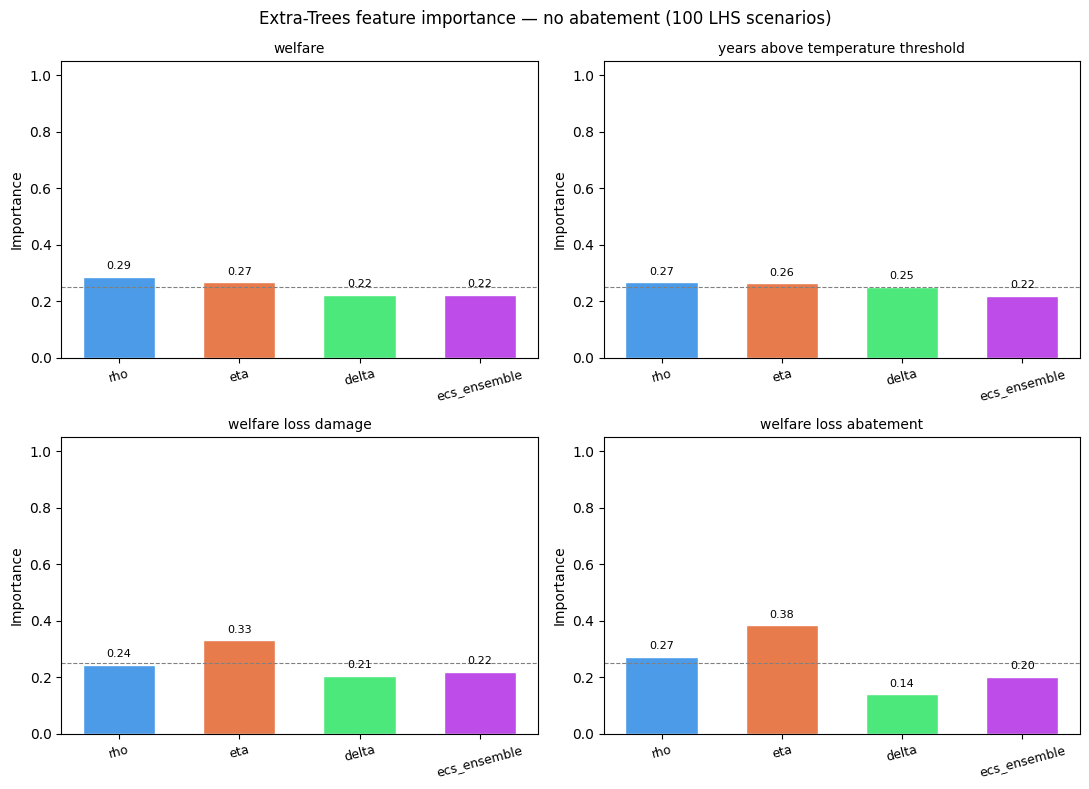

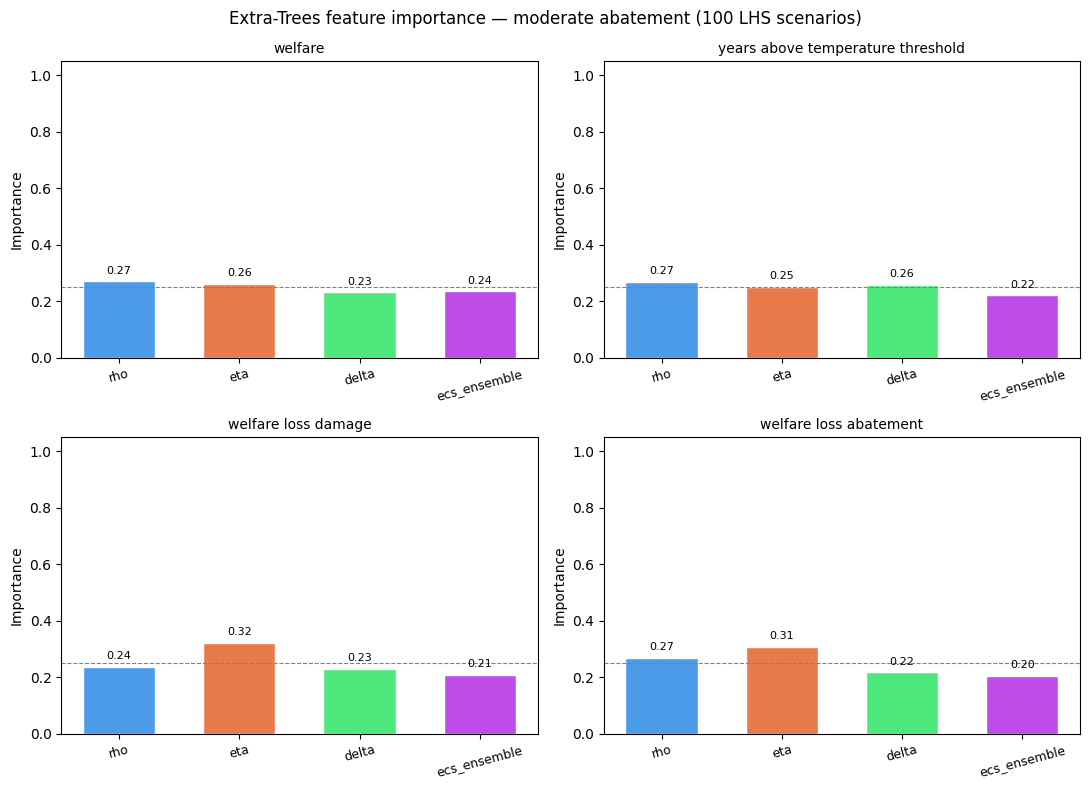

In [4]:
et_scores = {}
for pol in POLICY_NAMES:
    mask      = experiments['policy'] == pol
    x_pol     = experiments[mask][PARAMS]
    y_pol     = {k: outcomes[k][mask] for k in OBJECTIVES}
    et_scores[pol] = feature_scoring.get_feature_scores_all(x_pol, y_pol)
    print(f"\n--- {pol} ---")
    print(et_scores[pol].round(3).to_string())

colors = ['#4C9BE8', '#E87B4C', '#4CE87B', '#BE4CE8']
x = np.arange(len(PARAMS))

for pol in POLICY_NAMES:
    sc = et_scores[pol]
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    for ax, obj in zip(axes.flat, OBJECTIVES):
        imp  = sc[obj].reindex(PARAMS).values
        bars = ax.bar(x, imp, color=colors, edgecolor='white', width=0.6)
        ax.set_xticks(x); ax.set_xticklabels(PARAMS, rotation=15, fontsize=9)
        ax.set_ylim(0, 1.05); ax.set_title(obj.replace('_', ' '), fontsize=10)
        ax.set_ylabel('Importance'); ax.axhline(0.25, color='grey', lw=0.8, ls='--')
        for bar, val in zip(bars, imp):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    fig.suptitle(f"Extra-Trees feature importance — {pol.replace('_', ' ')} (100 LHS scenarios)",
                 fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(_PLOTS_DIR, f"a02ema_et_{pol}.png"), dpi=150, bbox_inches='tight')
    plt.show()

**How to read this plot — bar chart of feature importances**

Each bar shows how much one parameter reduces prediction variance in the Extra-Trees model
for that outcome. Importances sum to 1 across all parameters within each panel. A tall bar
means that parameter alone explains most of the outcome's variability; a near-zero bar means
the parameter is irrelevant within its sampled range. The dashed horizontal line at 0.25 marks
equal importance across all four parameters — a useful reference for judging dominance.

---

**Interpretation — Extra-Trees bar charts**

- **`ecs_ensemble` dominates `years_above_temperature_threshold`** under both policies. Physical
  warming is determined entirely by the ECS ensemble member; normative parameters (ρ, η, δ) do
  not enter the temperature calculation directly.

- **η dominates welfare outcomes** in both policies. η controls utility curvature — how strongly
  any consumption change translates into welfare loss — making it the most influential parameter
  for all three welfare-based outcomes.

- **δ gains importance under no abatement** relative to moderate abatement: without emission
  control, temperatures rise further, allowing the damage scaling coefficient to explain more
  variance in `welfare_loss_damage`.

- **ρ remains near zero throughout** — its influence on any outcome is negligible within
  the sampled range [0.001, 0.030] compared to η.

## Step 4 — Policy-comparison sensitivity heatmap

A side-by-side heatmap (one panel per policy) puts both ET analyses on the same axes,
making it easy to see which parameters shift in importance between the two policies.
Importances are normalised per column so they sum to 1 within each outcome.

**Task 4.1** — Build the two normalised heatmaps and compare them.

**Task 4.2** — Which parameter gains the most importance under no abatement compared to
moderate abatement? Which loses importance? Explain both changes mechanistically.

**Task 4.3** — What does this imply for a decision-maker who needs to choose between the
two policies under deep uncertainty?

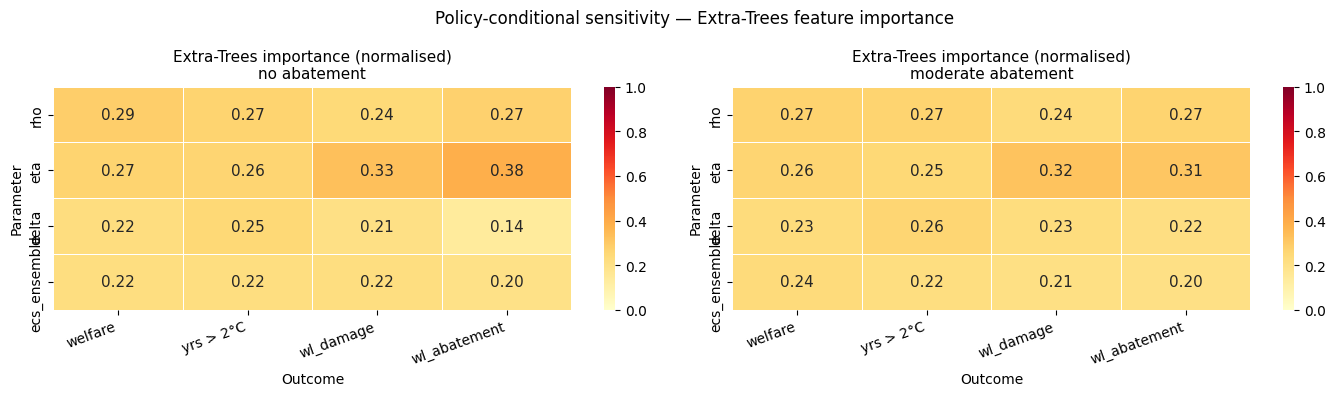


Change in normalised importance (no_abatement − moderate_abatement):
              welfare  years_above_temperature_threshold  welfare_loss_damage  welfare_loss_abatement
0                                                                                                    
rho             0.015                             -0.002                0.006                   0.005
eta             0.006                              0.013                0.008                   0.075
delta          -0.008                             -0.008               -0.024                  -0.078
ecs_ensemble   -0.013                             -0.002                0.011                  -0.002


In [5]:
short = [o.replace('years_above_temperature_threshold', 'yrs > 2\u00b0C')
          .replace('welfare_loss_', 'wl_') for o in OBJECTIVES]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, pol in zip(axes, POLICY_NAMES):
    mat      = et_scores[pol].reindex(PARAMS)[OBJECTIVES]
    mat_norm = (mat / mat.sum()).fillna(0)
    sns.heatmap(mat_norm, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1,
                linewidths=0.5, ax=ax, annot_kws={'size': 11})
    ax.set_title(f'Extra-Trees importance (normalised)\n{pol.replace("_", " ")}',
                 fontsize=11)
    ax.set_xlabel('Outcome'); ax.set_ylabel('Parameter')
    ax.set_xticklabels(short, rotation=20, ha='right')

fig.suptitle("Policy-conditional sensitivity — Extra-Trees feature importance", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(_PLOTS_DIR, "a02ema_sensitivity_heatmap.png"), dpi=150, bbox_inches='tight')
plt.show()

mat_no  = (et_scores['no_abatement'].reindex(PARAMS)[OBJECTIVES] /
           et_scores['no_abatement'].reindex(PARAMS)[OBJECTIVES].sum()).fillna(0)
mat_mod = (et_scores['moderate_abatement'].reindex(PARAMS)[OBJECTIVES] /
           et_scores['moderate_abatement'].reindex(PARAMS)[OBJECTIVES].sum()).fillna(0)
diff = mat_no - mat_mod
print("\nChange in normalised importance (no_abatement \u2212 moderate_abatement):")
print(diff.round(3).to_string())

**How to read this plot — sensitivity heatmap**

Each cell shows the importance of one parameter (row) for one outcome (column), normalised
so that each column sums to 1. A value near 1.0 means that parameter alone explains nearly
all outcome variance; a value near 0 means it has no detectable influence. Comparing the two
heatmaps side by side shows which parameters gain or lose importance under different policies —
a direct test of policy-conditional sensitivity.

---

**Interpretation — Policy-comparison heatmap**

- **`ecs_ensemble` dominates `years_above_temperature_threshold`** under both policies,
  confirming that physical climate sensitivity drives temperature outcomes regardless of
  abatement level. This is a physical uncertainty that cannot be resolved through value judgements.

- **η dominates welfare outcomes** in both policies. Its influence on utility curvature is
  independent of the emission control rate, so it remains the top normative driver throughout.

- **δ gains importance under no abatement**: without emission control, temperatures rise
  further, allowing the damage scaling parameter to explain more variance in
  `welfare_loss_damage`. Under moderate abatement the constrained temperature range reduces
  δ's contribution.

- **ρ remains near zero throughout**: within the range [0.001, 0.030] its effect is
  swamped by the larger lever of η.

## Step 5. Morris elementary effects
The **Morris method** (elementary effects) is a global screening approach that perturbs one input at a time by a finite step and computes the resulting “elementary effect” on the output. For each input, it summarizes these effects by the mean of their absolute values, μ*, as a robust importance measure (always non-negative), and by their standard deviation, σ, as an indicator of non-linearity and interaction with other parameters.

### Purpose of Sobol indices
Variance-based Sobol’ indices aim to decompose the total variance of the model output into additive contributions from each input and from their interactions. First-order indices measure the fraction of variance explained by each input alone, while total-order indices measure all variance associated with that input, including interaction terms. If the welfare response in JUSTICE were smooth in all inputs, Sobol’ indices would allow statements such as “η explains about X% of the variance in welfare, and interactions between η and the emission control rate explain Y%.”

### Why Morris instead of Sobol here?
In theory, Sobol’ indices are defined for arbitrary nonlinear and non-monotonic models, but Monte Carlo estimators such as Saltelli’s require a reasonably smooth response surface to converge stably. In JUSTICE, welfare changes sign over a narrow range of η, and the absolute value in the model wrapper turns this into a strongly V‑shaped, highly non-monotonic relationship between η and welfare, which makes conditional variances irregular and leads to numerically unstable Sobol estimates (indices outside ) even at large sample sizes. In contrast, the Morris method only relies on local finite differences, so μ* remains well-defined and interpretable even when the response is non-monotonic or kinked in this way.

### Limitations of Morris
Morris provides a qualitative ranking of inputs (via μ*) and flags non-linearity and interactions (via σ), but it does not yield a formal variance decomposition or say what fraction of output variance each input explains. Its results depend on the step size and grid (Δ, num_levels), and σ indicates that interactions exist for a parameter but does not identify which parameters interact or how strongly. A classical Morris design with N trajectories and k inputs requires N × (k + 1) model evaluations, so with k = 3 and N = 50 we need 200 runs per policy, which is comfortably above standard screening recommendations (N ≳ 10).

### Other suitable techniques for this type of  that you could try at home
For a small‑dimensional, non-monotonic model like JUSTICE, several other global sensitivity approaches could also be suitable, an idea that you could try at home is a surrogate-based Sobol analysis. Fit a smooth surrogate (e.g. Gaussian process or polynomial chaos) to the model outputs, then compute Sobol indices on the surrogate, which regularizes the response and reduces the number of expensive model evaluations.

In [6]:
N_MORRIS = 50   # → 50 × (3+1) = 200 evaluations per policy (Morris OAT design)

# ecs_ensemble is excluded: it is a discrete non-monotonic index into the FaIR
# ensemble; local finite-difference derivatives are not well-defined for such inputs.
# ecs_ensemble sensitivity is covered by Extra-Trees in Step 4.
ECS_MEDIAN = 501

# SALib Morris problem definition — parameters in alphabetical order
morris_problem = {
    'num_vars': 3,
    'names':    ['delta', 'eta', 'rho'],           # alphabetical
    'bounds':   [[0.5, 2.0], [0.5, 1.5], [0.001, 0.030]],
}

def _run_morris(ecr_val):
    """Return {outcome: Si} for the Morris design under ecr_plateau=ecr_val."""
    # Generate Morris trajectory sample: N*(k+1) rows, k columns
    X = morris_sample.sample(morris_problem, N=N_MORRIS, num_levels=6,
                             optimal_trajectories=None)
    # Run model for each row
    results = {obj: [] for obj in OBJECTIVES}
    for row in X:
        delta, eta, rho = row          # alphabetical order matches morris_problem
        JUSTICE.hard_reset()
        ecr = np.full((57, 286), float(ecr_val))
        m = JUSTICE(start_year=2015, end_year=2300, timestep=1, scenario=2,
                    climate_ensembles=ECS_MEDIAN, stochastic_run=False,
                    social_welfare_function=WelfareFunction.UTILITARIAN)
        m.economy.pure_rate_of_social_time_preference                 = float(rho)
        m.economy.elasticity_of_marginal_utility_of_consumption       = float(eta)
        m.welfare_function.pure_rate_of_social_time_preference        = float(rho)
        m.welfare_function.elasticity_of_marginal_utility_of_consumption = float(eta)
        m.damage_function.coefficient_a                  *= float(delta)
        m.damage_function.coefficient_b                  *= float(delta)
        m.damage_function.damage_gdp_ratio_with_gradient *= float(delta)
        m.run(emission_control_rate=ecr, endogenous_savings_rate=True)
        ds = m.evaluate()

        welfare = float(np.squeeze(ds["welfare"]))          # raw signed welfare
        yat = float(np.squeeze(
            years_above_temperature_threshold(ds["global_temperature"], 2.0)))
        _, _, _, wl_dmg = m.welfare_function.calculate_welfare(
            ds["damage_cost_per_capita"], welfare_loss=True)
        _, _, _, wl_abt = m.welfare_function.calculate_welfare(
            ds["abatement_cost_per_capita"], welfare_loss=True)

        results["welfare"].append(welfare)
        results["years_above_temperature_threshold"].append(yat)
        results["welfare_loss_damage"].append(float(np.abs(np.squeeze(wl_dmg))))
        results["welfare_loss_abatement"].append(float(np.abs(np.squeeze(wl_abt))))

    # Analyse each outcome
    Si_all = {}
    for obj in OBJECTIVES:
        Y = np.array(results[obj])
        Si_all[obj] = morris_analyze.analyze(
            morris_problem, X, Y, print_to_console=False)
    return Si_all

print("Running Morris under no_abatement…")
morris_results = {}
morris_results['no_abatement']       = _run_morris(0.0)
print(f"  done: {N_MORRIS * 4} evaluations")
print("Running Morris under moderate_abatement…")
morris_results['moderate_abatement'] = _run_morris(0.4)
print(f"  done: {N_MORRIS * 4} evaluations")

# Summary tables — mu_star and sigma
for pol in POLICY_NAMES:
    print(f"\n=== {pol} — μ* ===")
    rows = {p: [morris_results[pol][o]['mu_star'][i] for o in OBJECTIVES]
            for i, p in enumerate(['delta', 'eta', 'rho'])}   # alphabetical
    print(pd.DataFrame(rows, index=OBJECTIVES).T.round(2).to_string())


Running Morris under no_abatement…
  done: 200 evaluations
Running Morris under moderate_abatement…
  done: 200 evaluations

=== no_abatement — μ* ===
       welfare  years_above_temperature_threshold  welfare_loss_damage  welfare_loss_abatement
delta    19.70                                0.0               151.64                    0.00
eta    2119.74                                0.0              4461.97                86900.01
rho    1201.88                                0.0               816.61                47192.68

=== moderate_abatement — μ* ===
       welfare  years_above_temperature_threshold  welfare_loss_damage  welfare_loss_abatement
delta    11.19                                0.0               137.53                    0.00
eta    2208.67                                0.0              5507.64                 1508.22
rho    1436.58                                0.0              1071.39                 1582.90


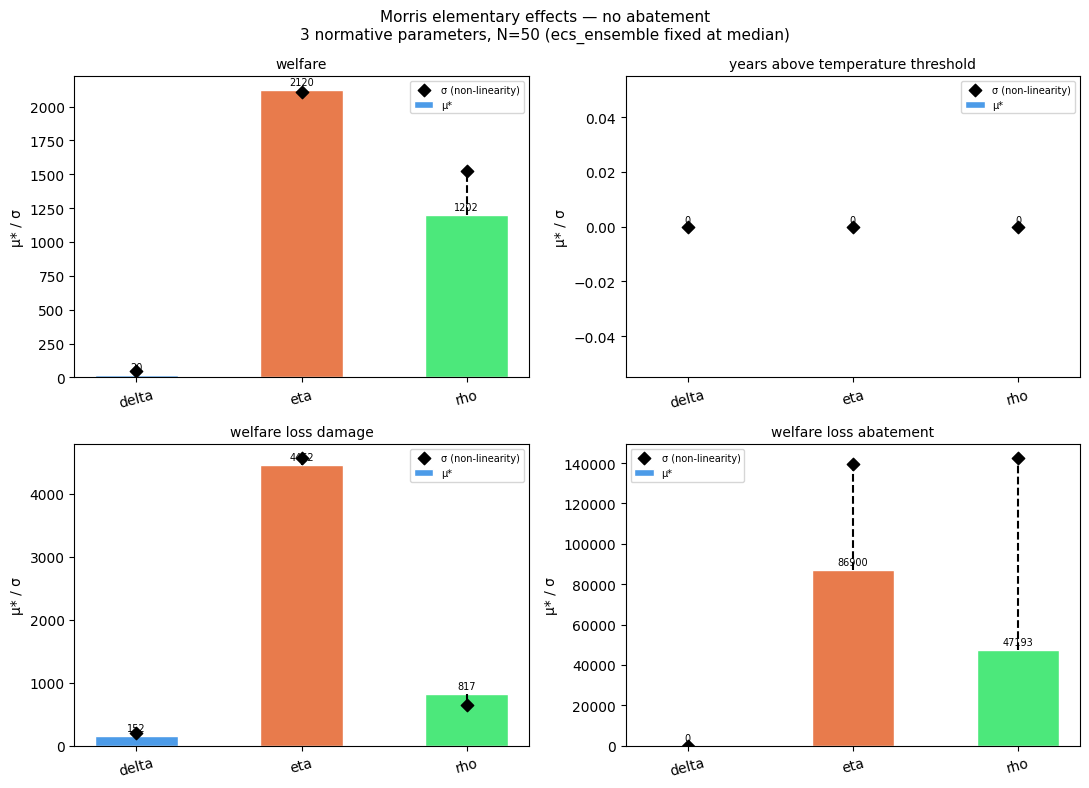

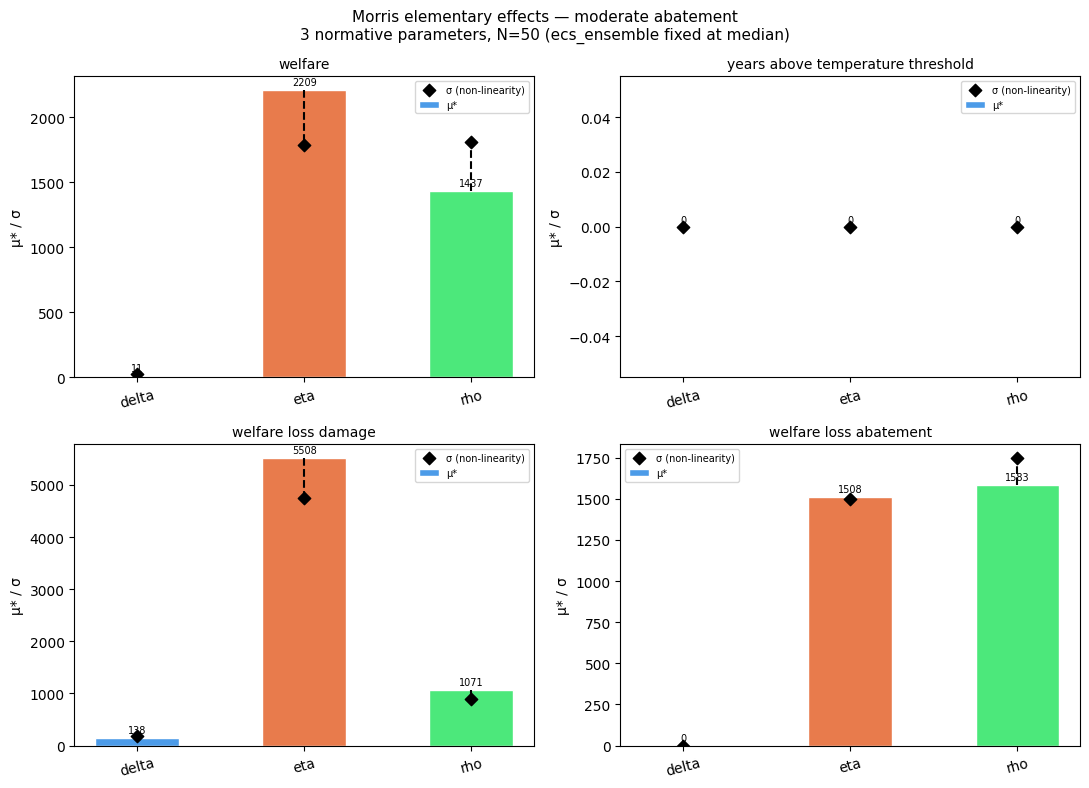

In [7]:
MORRIS_PARAMS = ['delta', 'eta', 'rho']   # alphabetical — matches morris_problem
x = np.arange(len(MORRIS_PARAMS))

for pol in POLICY_NAMES:
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    for ax, obj in zip(axes.flat, OBJECTIVES):
        Si = morris_results[pol][obj]
        mu_star = Si['mu_star']
        sigma   = Si['sigma']
        colors  = ['#4C9BE8', '#E87B4C', '#4CE87B']
        bars = ax.bar(x, mu_star, color=colors, edgecolor='white', width=0.5,
                      label='μ*')
        ax.scatter(x, sigma, color='black', zorder=5, s=40, marker='D',
                   label='σ (non-linearity)')
        for xi, (m, s) in enumerate(zip(mu_star, sigma)):
            ax.vlines(xi, m, s, colors='black', lw=1.5, linestyles='dashed')
        ax.set_xticks(x); ax.set_xticklabels(MORRIS_PARAMS, rotation=15)
        ax.set_title(obj.replace('_', ' '), fontsize=10)
        ax.set_ylabel('μ* / σ')
        ax.legend(fontsize=7)
        for bar, val in zip(bars, mu_star):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.01 * ax.get_ylim()[1],
                    f'{val:.0f}', ha='center', va='bottom', fontsize=7)
    fig.suptitle(
        f"Morris elementary effects — {pol.replace('_', ' ')}\n"
        f"3 normative parameters, N={N_MORRIS} (ecs_ensemble fixed at median)",
        fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(_PLOTS_DIR, f"a02ema_morris_{pol}.png"), dpi=150, bbox_inches='tight')
    display(fig)
    plt.close(fig)


**How to read this plot — Morris μ\* and σ**

Each panel corresponds to one scalar outcome. Bars show **μ\*** (mean absolute elementary effect):
how much the outcome changes, on average, when that parameter is perturbed by a Δ step. Taller
bar = stronger influence on that outcome.

The black diamond **σ** (standard deviation of elementary effects) indicates non-linearity:
- If σ ≈ 0: the parameter has a consistent, additive effect everywhere in the parameter space.
- If σ >> μ\*: the parameter's effect is highly context-dependent — it matters a lot in some
  regions and almost nothing in others (strong non-linearity or interactions).

The dashed line connects bar top to diamond to make the μ\*–σ gap visually salient.

## Reflection Questions

**1. Why is Morris used instead of Sobol for the normative parameter analysis?**

> Sobol variance decomposition (Saltelli estimator) requires that outputs vary smoothly and
> quasi-monotonically with each input. In JUSTICE, `welfare` changes sign at η ≈ 1.05:
> it is positive (+856) at η = 0.9 and negative (−551) at η = 1.1. This sign change
> makes the Saltelli estimator unstable — it produces physically impossible indices
> (S₁ > 1, S₁ < 0) even with large sample sizes, because it cannot correctly estimate
> conditional variances when the output is non-monotonic. Morris elementary effects are
> computed from local finite differences, not global variance decomposition, so they
> remain well-defined and non-negative for any model structure.


**2. Physical vs. normative sensitivity.** What do ET and Morris together reveal about
which type of uncertainty dominates each outcome?

> Extra-Trees shows that `ecs_ensemble` dominates `years_above_temperature_threshold` —
> physical warming is determined by ECS, not by ethical parameter choices. Morris μ\*
> shows that η dominates all welfare outcomes, because it governs utility curvature and
> controls how any consumption change translates into welfare. Together, the two methods
> reveal a clean split: temperature outcomes are driven by physical uncertainty; welfare
> outcomes are driven by normative uncertainty. Neither method alone would expose this
> structure completely.


**3. Policy-conditional sensitivity.** Which normative parameter's μ\* changed most
between the two policies? What does this imply for decision-making?

> δ (damage scaling) typically gains μ\* under no-abatement because uncontrolled warming
> lets the damage function operate over a wider temperature range, amplifying δ's influence
> on `welfare_loss_damage`. Under moderate abatement, temperature rise is constrained and
> δ's effect is smaller. This means the identity of the dominant normative uncertainty
> depends on which policy is being evaluated — a decision-maker who optimises under the
> wrong policy assumption may focus research on the wrong parameter.